# Градиентный бустинг

Исследуем влияние learning rate и числа деревьев, выберем конфигурацию по ROC-AUC и проанализируем качество и важность признаков.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

In [2]:
data = pd.read_csv("data.csv")
features = data.drop(columns="target")
target = data["target"]
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)
print("Размер:", data.shape)
display(target.value_counts().to_frame("count"))

Размер: (569, 31)


,count
target,
1,357
0,212


## Подбор базовых параметров

,learning_rate,n_estimators,roc_auc
15,0.20,200,0.994549
11,0.10,200,0.994130
14,0.20,100,0.993920
12,0.20,25,0.993711
3,0.03,200,0.993501


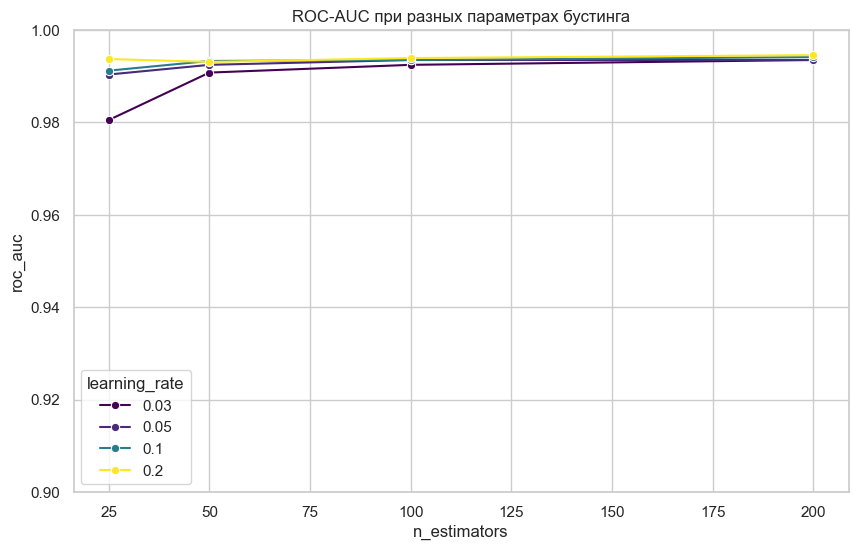

In [3]:
rows = []
for learning_rate in [0.03, 0.05, 0.1, 0.2]:
    for n_estimators in [25, 50, 100, 200]:
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            random_state=42,
        )
        model.fit(train_features, train_target)
        probability = model.predict_proba(test_features)[:, 1]
        rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "roc_auc": roc_auc_score(test_target, probability),
        })

experiments = pd.DataFrame(rows)
display(experiments.sort_values("roc_auc", ascending=False).head())

plt.figure(figsize=(10, 6))
sns.lineplot(data=experiments, x="n_estimators", y="roc_auc", hue="learning_rate", marker="o", palette="viridis")
plt.title("ROC-AUC при разных параметрах бустинга")
plt.ylim(0.9, 1.0)
plt.show()

## Лучшая конфигурация

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


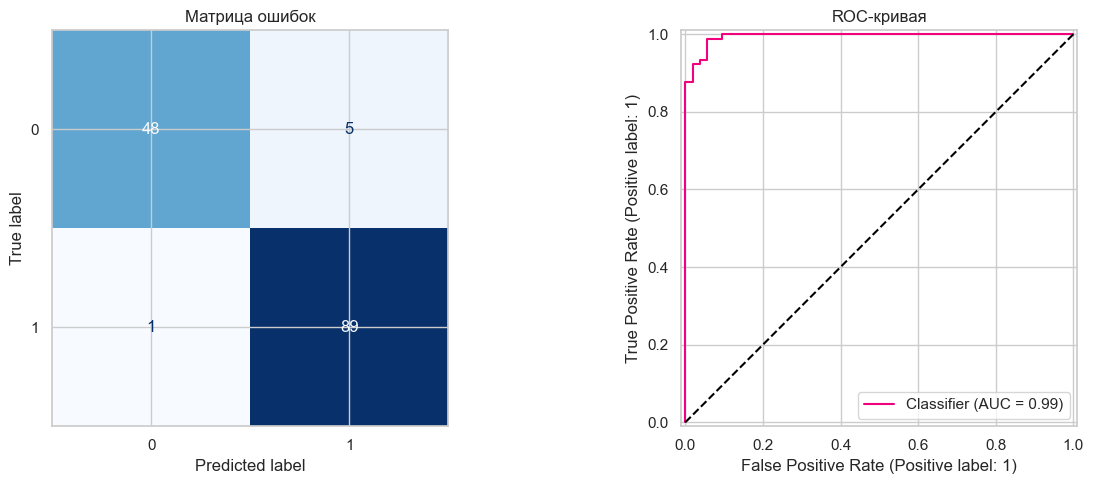

In [4]:
best = experiments.sort_values("roc_auc", ascending=False).iloc[0]
best_model = GradientBoostingClassifier(
    learning_rate=float(best["learning_rate"]),
    n_estimators=int(best["n_estimators"]),
    max_depth=2,
    random_state=42,
)
best_model.fit(train_features, train_target)
prediction = best_model.predict(test_features)
probability = best_model.predict_proba(test_features)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(test_target, prediction, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Матрица ошибок")
RocCurveDisplay.from_predictions(test_target, probability, ax=axes[1], color="#f0027f")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[1].set_title("ROC-кривая")
plt.tight_layout()
plt.show()

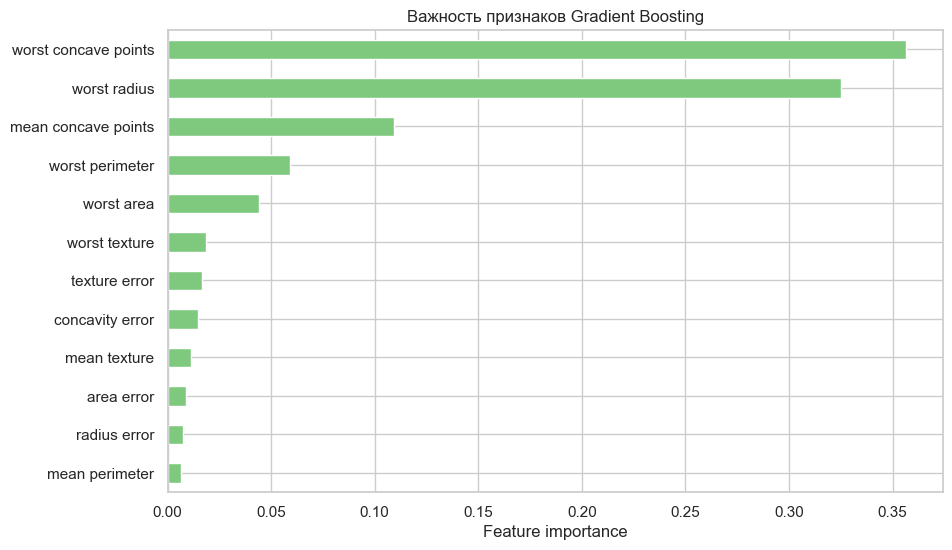

In [5]:
importance = pd.Series(best_model.feature_importances_, index=features.columns).nlargest(12).sort_values()
importance.plot.barh(figsize=(10, 6), color="#7fc97f")
plt.title("Важность признаков Gradient Boosting")
plt.xlabel("Feature importance")
plt.show()

## Вывод

Learning rate и число деревьев связаны: меньший шаг обычно требует больше итераций. Подбор выполняется на валидации, а test-выборка должна использоваться только для итоговой оценки.

## Расширенный анализ процесса бустинга

In [6]:
import numpy as np
from sklearn.calibration import CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.model_selection import StratifiedKFold, learning_curve

### Baseline и качество лучшей модели

In [7]:
dummy = DummyClassifier(strategy="prior").fit(train_features, train_target)
dummy_probability = dummy.predict_proba(test_features)[:, 1]

pd.DataFrame({
    "model": ["Dummy prior", "Gradient Boosting"],
    "roc_auc": [
        roc_auc_score(test_target, dummy_probability),
        roc_auc_score(test_target, probability),
    ],
    "brier": [
        brier_score_loss(test_target, dummy_probability),
        brier_score_loss(test_target, probability),
    ],
})

,model,roc_auc,brier
0,Dummy prior,0.500000,0.233270
1,Gradient Boosting,0.994549,0.032955


### Динамика качества по итерациям

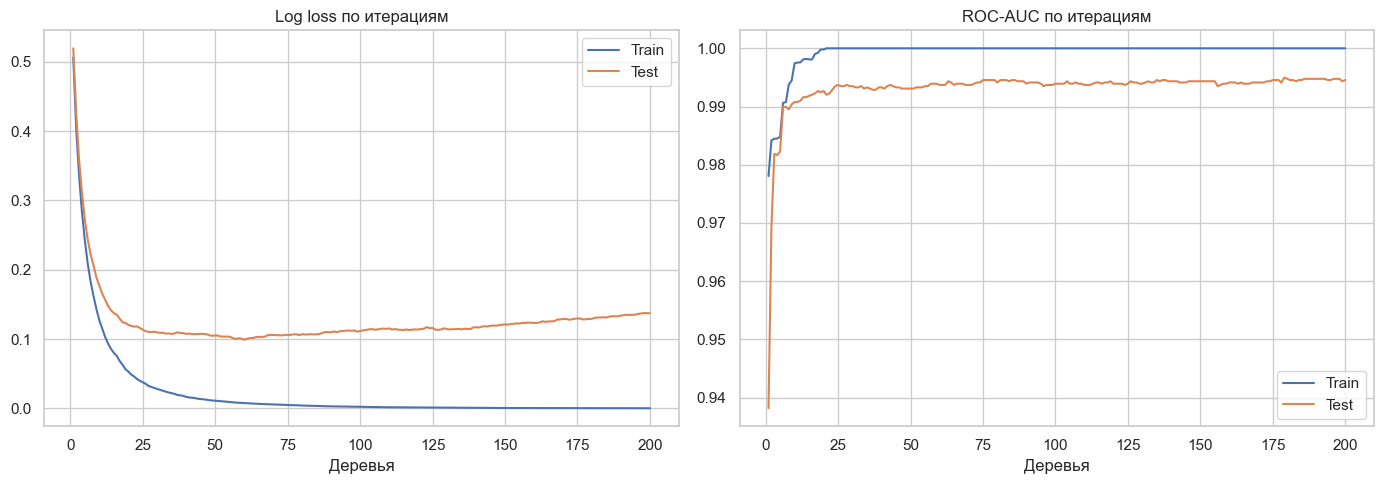

In [8]:
stage_rows = []
for stage, (train_probability, test_probability) in enumerate(
    zip(best_model.staged_predict_proba(train_features), best_model.staged_predict_proba(test_features)),
    start=1,
):
    stage_rows.append({
        "stage": stage,
        "train_logloss": log_loss(train_target, train_probability[:, 1]),
        "test_logloss": log_loss(test_target, test_probability[:, 1]),
        "train_auc": roc_auc_score(train_target, train_probability[:, 1]),
        "test_auc": roc_auc_score(test_target, test_probability[:, 1]),
    })

stage_results = pd.DataFrame(stage_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(stage_results["stage"], stage_results["train_logloss"], label="Train")
axes[0].plot(stage_results["stage"], stage_results["test_logloss"], label="Test")
axes[0].set_title("Log loss по итерациям")
axes[0].set_xlabel("Деревья")
axes[0].legend()
axes[1].plot(stage_results["stage"], stage_results["train_auc"], label="Train")
axes[1].plot(stage_results["stage"], stage_results["test_auc"], label="Test")
axes[1].set_title("ROC-AUC по итерациям")
axes[1].set_xlabel("Деревья")
axes[1].legend()
plt.tight_layout()
plt.show()

### Карта гиперпараметров

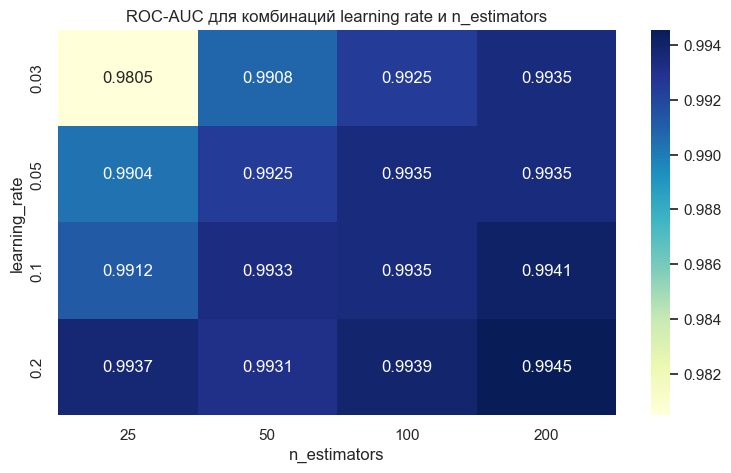

In [9]:
experiment_matrix = experiments.pivot(index="learning_rate", columns="n_estimators", values="roc_auc")
plt.figure(figsize=(9, 5))
sns.heatmap(experiment_matrix, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("ROC-AUC для комбинаций learning rate и n_estimators")
plt.show()

### Калибровка

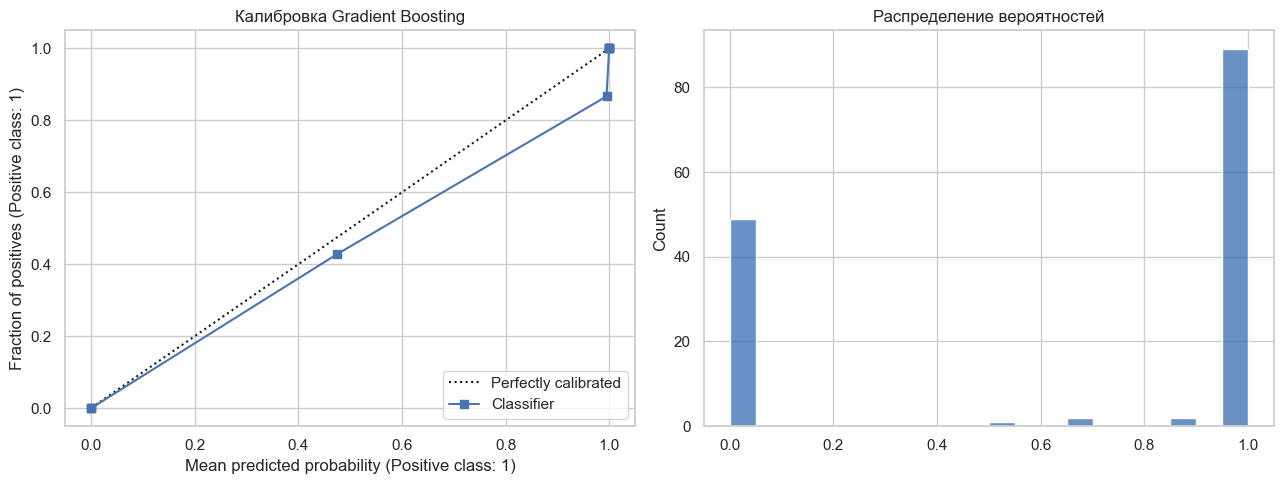

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
CalibrationDisplay.from_predictions(test_target, probability, n_bins=10, strategy="quantile", ax=axes[0])
axes[0].set_title("Калибровка Gradient Boosting")
sns.histplot(probability, bins=20, ax=axes[1], color="#386cb0")
axes[1].set_title("Распределение вероятностей")
plt.tight_layout()
plt.show()

### Partial dependence

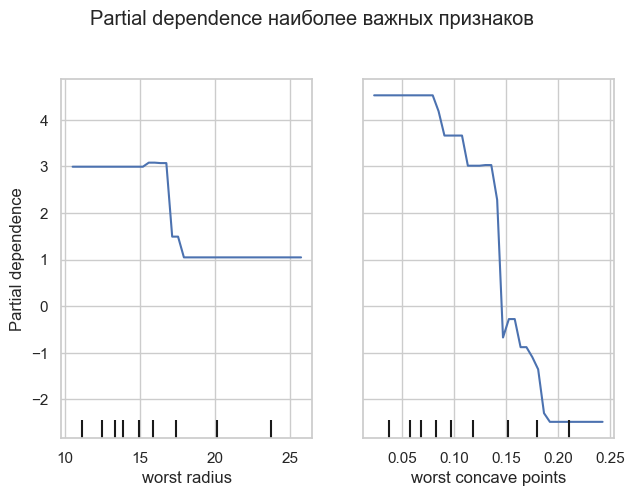

In [11]:
top_feature_indices = np.argsort(best_model.feature_importances_)[-2:]
top_feature_names = features.columns[top_feature_indices].tolist()
PartialDependenceDisplay.from_estimator(
    best_model,
    train_features,
    features=top_feature_names,
    grid_resolution=40,
    kind="average",
)
plt.suptitle("Partial dependence наиболее важных признаков", y=1.03)
plt.tight_layout()
plt.show()

### Learning curve

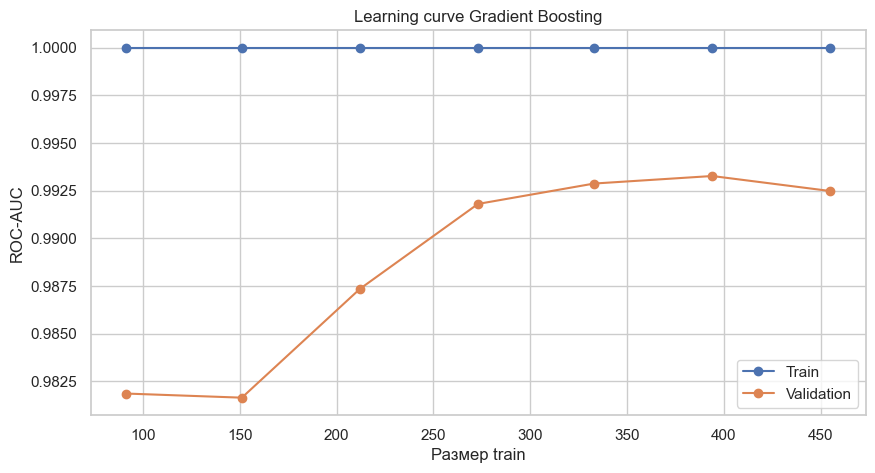

In [12]:
validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sizes, train_scores, validation_scores = learning_curve(
    best_model,
    features,
    target,
    cv=validation,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 7),
)

plt.figure(figsize=(10, 5))
plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(sizes, validation_scores.mean(axis=1), marker="o", label="Validation")
plt.title("Learning curve Gradient Boosting")
plt.xlabel("Размер train")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

### Итог расширенного анализа

Staged-предсказания показывают момент, после которого дополнительные деревья улучшают train, но перестают улучшать test. Learning rate управляет вкладом каждого дерева, калибровка проверяет качество вероятностей, а partial dependence помогает интерпретировать нелинейные зависимости.